<h1>Python/NumPy basics</h1>

In [1]:
import numpy as np

import pandas as pd

import matplotlib
from matplotlib import pyplot as plt

from pandas import DataFrame, Series

import seaborn as sns

from sklearn.datasets import load_iris

In [120]:
iris = load_iris()

In [2]:
data = pd.read_csv("iris.data")

In [4]:
df = DataFrame(data)
df.columns = ["sep-len", "sep-wid", "pet-len", "pet-wid", "class"]
df.head()

,sep-len,sep-wid,pet-len,pet-wid,class
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa


<h2>Answer to question 1</h2>

<p>Plot the data points using the first two dimensions (Sepal Length and Sepal Width).</p>

<AxesSubplot:xlabel='sep-len', ylabel='sep-wid'>

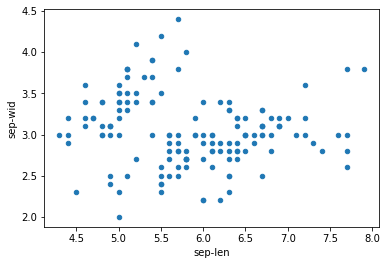

In [7]:
df.plot.scatter(x = "sep-len", y = "sep-wid")

<h2>Answer to question 2</h2>

<p>Use three different shapes (triangle, square, circle) to plot datapoints for three different classes.
You should use the class information from class label and use them when you decide on shape</p>

In [14]:
classes = set(df["class"])
classes = list(classes)
classes

['Iris-setosa', 'Iris-virginica', 'Iris-versicolor']

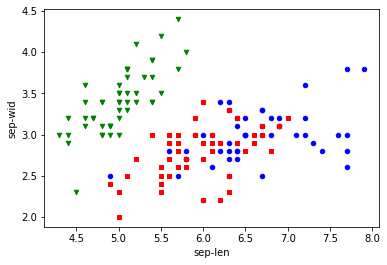

In [18]:
plot_area = None
markers = ["v", "o", "s"]
colors = ["g", "b", "r"]
for vari in classes:
    plot_area = df[df["class"] == vari].plot.scatter(x = "sep-len", y = "sep-wid", marker = markers.pop(0), 
                                                     color = colors.pop(0), ax = plot_area)

<h2>Answer to question 3</h2>

<p>Calculate the mean data point for each class and show them with similar shape with the larger size</p>

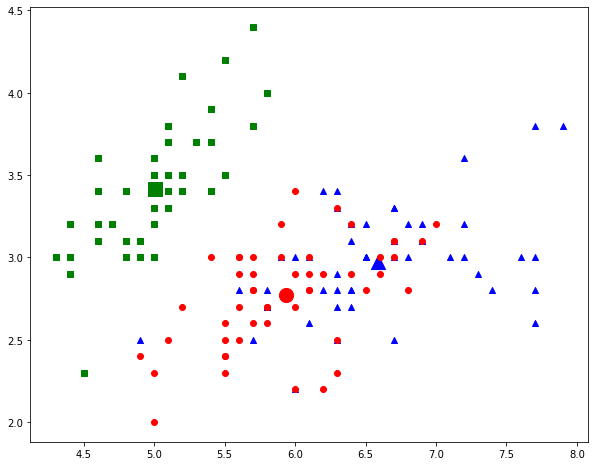

In [60]:
plt.figure(figsize=(10, 8))

sp_mean = df.groupby('class').mean()
to_mean = df.mean()
means = sp_mean.append(to_mean, ignore_index=True)
means.insert( 0, 'species', ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica', 'all_species'])
means = means.drop(3)
df3 = DataFrame(means)
df3

#plot_area = None
markers = ["s", "s","^","^", "o","o"]
colors = ["g", "g", "b","b","r", "r"]
for vari in classes:
    
    plt.scatter(df[df["class"] == vari].values[:, 0], df[df["class"] == vari].values[:, 1], marker = markers.pop(0),color = colors.pop(0))
    plt.scatter(df3[df3["species"] == vari].values[:, 1], df3[df3["species"] == vari].values[:, 2], marker = markers.pop(0),color = colors.pop(0), s = 200)
    
    '''
    plot_area = df[df["class"] == vari].plot.scatter(x = "sep-len", y = "sep-wid", marker = markers.pop(0), 
                                                    color = colors.pop(0), ax = plot_area)
    plot_area = df3[df3["species"] == vari].plot.scatter(x = "sep-len", y = "sep-wid", marker = markers.pop(0), 
                                                     color = colors.pop(0), ax = plot_area, s = 150)
    '''                                                 
plt.show()

<h2>Answer to question 4</h2>

<p>Now, plot a line (l) in this plot with line equation. The line is l = span{[−2.75 2.75]}. Therefore, the equation of the line is: x2=-x1</p>

In [63]:
sepl_mean = df["sep-len"].mean()
sepw_mean = df["sep-wid"].mean()



miu_sepl = np.ones((149,1)) * sepl_mean
t = df.values[:,0] - miu_sepl.T
df["sep-len"] = t.T


miu_sepw = np.ones((149,1)) * sepw_mean
u = df.values[:,1] - miu_sepw.T
df["sep-wid"] = u.T


In [65]:
df["sep-wid"]

0     -0.051007
1      0.148993
2      0.048993
3      0.548993
4      0.848993
         ...   
144   -0.051007
145   -0.551007
146   -0.051007
147    0.348993
148   -0.051007
Name: sep-wid, Length: 149, dtype: object

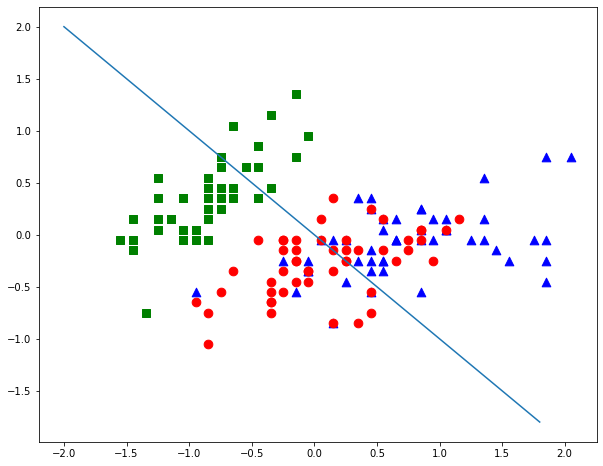

In [80]:
plt.figure(figsize=(10, 8))

markers = ["s", "^", "o"]
colors = ["g", "b", "r"]
for vari in classes:
    
    plt.scatter(df[df["class"] == vari].values[:, 0], df[df["class"] == vari].values[:, 1], marker = markers.pop(0),
                color = colors.pop(0), s= 75)


    
x1 = np.arange(-2, 2, .2)
x2 = -x1
plt.plot(x1,x2)

<h2>Answer to question 5</h2>

<p>Now calculate the projection of each data points on the line l (spanned by the vector [−2.75 2.75]. And plot the projected point on the line using the same shape but smaller size. So all smaller shapes would be on the line</p>

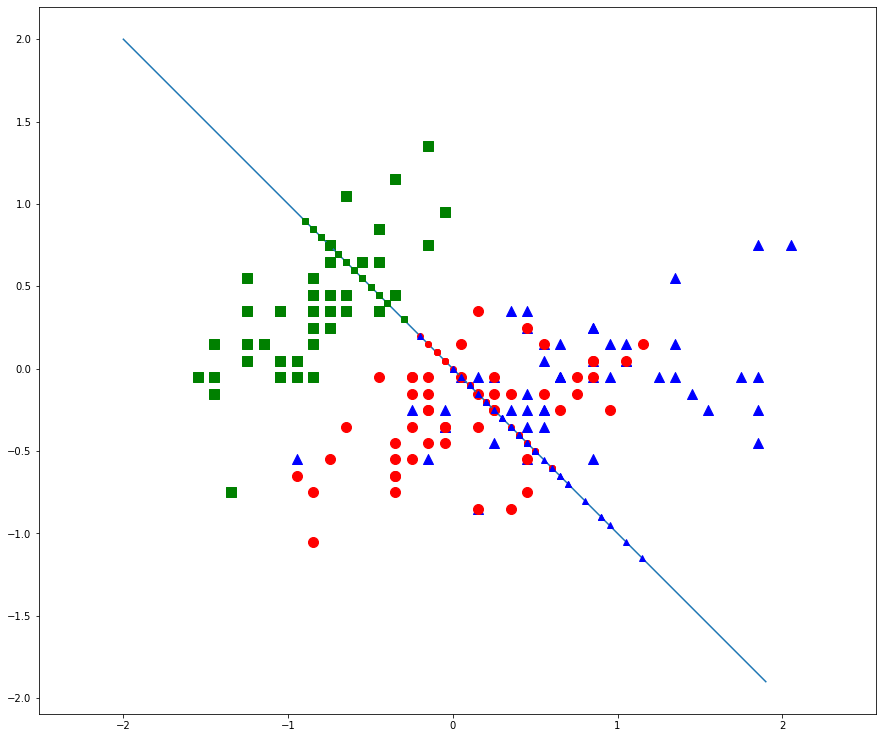

In [119]:
plt.figure(figsize=(15, 13))

x1 = np.arange(-2, 2, .1)
x2 = -x1
plt.plot(x1,x2)

def point_on_line(a, b, p):
    ap = p - a
    ab = b - a
    result = a + np.dot(ap, ab) / np.dot(ab, ab) * ab
    return result

markers = ["s", "^", "o"]
colors = ["g", "b", "r"]

plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.axis('equal')

for vari in classes:
    
    plt.scatter(df[df["class"] == vari].values[:, 0], df[df["class"] == vari].values[:, 1], marker = markers.pop(0),color = colors.pop(0), s=100 )

    
A = np.array([2, -2])
B = np.array([-2, 2])


    
for i in range(0, len(df[df["class"] == "Iris-setosa"].index)):
        
    P = np.array([(df["sep-len"].values[i]), (df["sep-wid"].values[i])])
  

    projected = point_on_line(A, B, P)
    plt.plot(projected[0], projected[1], 'gs')

    
for i in range(50, 100):
        

    P = np.array([(df["sep-len"].values[i]), (df["sep-wid"].values[i])])

    projected = point_on_line(A, B, P)
    plt.plot(projected[0], projected[1], 'ro' )
    

for i in range(101, 149):
        
    r = df["sep-len"].values[i]
    q = df["sep-wid"].values[i]

    P = np.array([r, q])


    projected = point_on_line(A, B, P)
    plt.plot(projected[0], projected[1], 'b^' )

<h2>Answer to question 6</h2>

<p>Draw the normal distribution function for all the sepal length (X1) . To do that, first calculate sample mean(μ1) and sample variance</p>

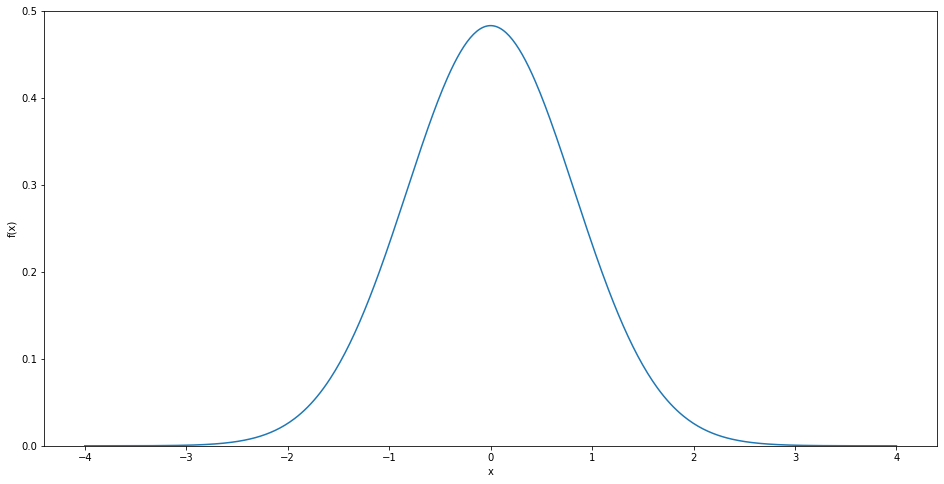

In [137]:

plt.figure(figsize=(16,8))

seplen_all = df.values[:, 0]
meean = np.mean(seplen_all)
variance = np.var(seplen_all)

x = np.linspace(-4, 4, 500)
y = (1 / np.sqrt(2 * np.pi * variance)) * (np.exp(-((x-meean)**2) / (2 * variance)))



plt.plot(x, y)


plt.xlabel("x")
plt.ylabel("f(x)")
plt.ylim(0.0, 0.5)
plt.show()

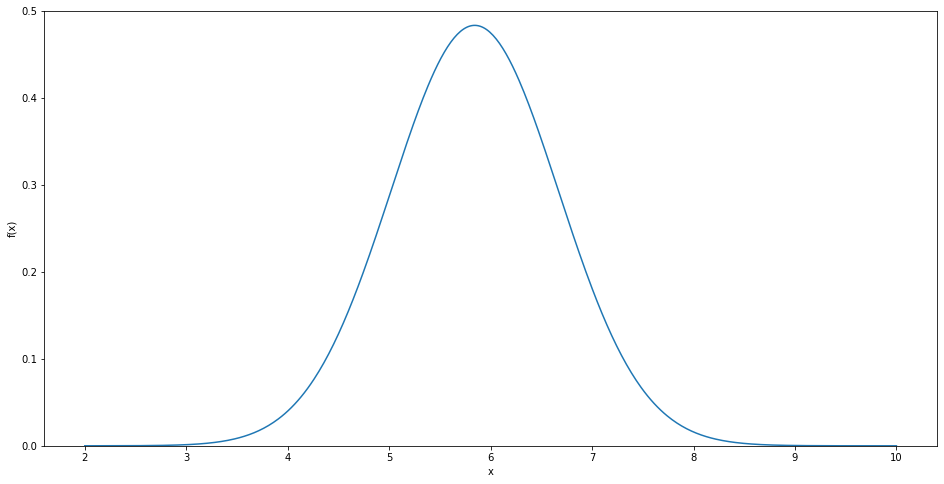

In [154]:
data = iris.data

plt.figure(figsize=(16,8))

seplen_all = data[:, 0]
meean = np.mean(seplen_all)
variance = np.var(seplen_all)

x = np.linspace(2, 10 , 500)
y = (1 / np.sqrt(2 * np.pi * variance)) * np.exp(-((x-meean)**2) / (2 * variance))



plt.plot(x, y)


plt.xlabel("x")
plt.ylabel("f(x)")
plt.ylim(0.0, 0.5)
plt.show()

<h2>Answer to question 7</h2>

<p>Draw the bivariate normal distribution function for the sepal length (X1) and the Sepal Width (X2). So you need to draw the function f(X1,X2). To do that, first calculate sample sepal length mean(μ1), sample sepal width mean(μ2), and the covariance matrix ∑</p>

In [166]:

x = np.arange(0, 10, 0.1)
y = np.arange(0, 10, 0.1)
X, Y = np.meshgrid(x, y)
X

array([[0. , 0.1, 0.2, ..., 9.7, 9.8, 9.9],
       [0. , 0.1, 0.2, ..., 9.7, 9.8, 9.9],
       [0. , 0.1, 0.2, ..., 9.7, 9.8, 9.9],
       ...,
       [0. , 0.1, 0.2, ..., 9.7, 9.8, 9.9],
       [0. , 0.1, 0.2, ..., 9.7, 9.8, 9.9],
       [0. , 0.1, 0.2, ..., 9.7, 9.8, 9.9]])

In [155]:
mnsl = np.mean(data[:, 0])
mnsw = np.mean(data[:, 1])
mn = np.array([mnsl, mnsw])
mn

array([5.84333333, 3.05733333])

In [157]:
bl = np.array(data[:, 0])
sl = np.array(data[:, 1])
bl_sl = np.array([bl, sl])
cov = np.cov(bl_sl)
cov

array([[ 0.68569351, -0.042434  ],
       [-0.042434  ,  0.18997942]])

In [158]:
cov_inv = np.linalg.inv(cov)
cov_det = np.linalg.det(cov)
cov_det
cov_inv

array([[1.47881871, 0.33031052],
       [0.33031052, 5.33750659]])

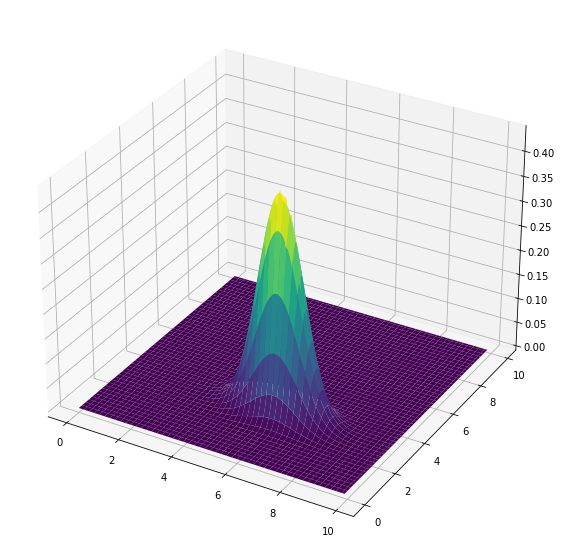

In [170]:
from mpl_toolkits import mplot3d
from scipy.stats import multivariate_normal


pos = np.dstack((X, Y))


rv = multivariate_normal(mn, cov)
Z = rv.pdf(pos)
fig = plt.figure(figsize=(20,10))

ax = fig.add_subplot(projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
plt.show()

<h1>Numeric Data Analysis</h1>